## GenAI Disclosure Statement

In this course, generative artificial intelligence (GenAI) tools were used as learning aids to support understanding of Responsible ML concepts and workflow design. Specifically, OpenAI Codex/ChatGPT was used during brainstorming, preparatory research, and exploratory analysis.

This work is disclosed with integrity and transparency. All AI-assisted outputs were critically reviewed, validated, and revised by the student before submission. The submitted notebook reflects the student's own final intellectual work.


# Compas Analysis (Python Version)

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

This notebook is a faithful Python translation of the original R-based lecture notebook (`Lecture-01-alignment.ipynb`).

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

## SECTION 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## SECTION 2: Load Data

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))

7214


In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

## SECTION 3: Data Cleaning and Filtering

In [4]:
# Select the same columns used in the R workflow
cols_to_keep = ["age", "c_charge_degree", "race", "age_cat",
                "score_text", "sex", "priors_count",
                "days_b_screening_arrest", "decile_score", "is_recid",
                "two_year_recid", "c_jail_in", "c_jail_out"]

df = raw_data[cols_to_keep].copy()

# ── Filtering (same conditions as R) ──
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

df.reset_index(drop=True, inplace=True)

# ── Type conversions ──
datetime_vars = ["c_jail_in", "c_jail_out"]
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Convert categorical columns to pandas Categorical type (equivalent to R factors)
factor_cols = ["c_charge_degree", "race", "age_cat", "score_text", "sex",
               "is_recid", "two_year_recid"]
for col in factor_cols:
    df[col] = df[col].astype(str).astype("category")

print(len(df))

6172


## SECTION 4: Feature Engineering

Create derived factor variables matching the R workflow:
- `crime_factor` from `c_charge_degree`
- `age_factor` from `age_cat` with reference level "25 - 45"
- `race_factor` from `race` with reference level "Caucasian"
- `gender_factor` from `sex` with reference level "Male"
- `score_factor`: "LowScore" if `score_text == "Low"`, else "HighScore"

In [5]:
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic",
                "Native American", "Other"]
)

# In R, the labels are applied as c("Female", "Male") and reference is "Male".
# The sex column already contains "Female" and "Male", so we just set the reference.
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

# score_factor: "LowScore" if score_text == "Low", else "HighScore"
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

In [6]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore
5,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,F,25 - 45,Other,Male,LowScore


In [7]:
df.dtypes

age                                 int64
c_charge_degree                  category
race                             category
age_cat                          category
score_text                       category
sex                              category
priors_count                        int64
days_b_screening_arrest           float64
decile_score                        int64
is_recid                         category
two_year_recid                   category
c_jail_in                  datetime64[us]
c_jail_out                 datetime64[us]
crime_factor                     category
age_factor                       category
race_factor                      category
gender_factor                    category
score_factor                     category
dtype: object

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [8]:
df["length_of_stay"] = (df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()).dt.days
print(df["length_of_stay"].corr(df["decile_score"]))

0.20732969161470446


## SECTION 5: EDA

After filtering we have the following demographic breakdown:

In [9]:
# Equivalent to R: summary(df$age_cat)
print(df["age_cat"].value_counts().reindex(["25 - 45", "Greater than 45", "Less than 25"]))

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [10]:
# Equivalent to R: summary(df$race)
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [11]:
n_total = len(df)
print("Black defendants: %.2f%%"      % (df["race"].value_counts()["African-American"] / n_total * 100))
print("White defendants: %.2f%%"      % (df["race"].value_counts()["Caucasian"]         / n_total * 100))
print("Hispanic defendants: %.2f%%"   % (df["race"].value_counts()["Hispanic"]          / n_total * 100))
print("Asian defendants: %.2f%%"      % (df["race"].value_counts()["Asian"]             / n_total * 100))
print("Native American defendants: %.2f%%" % (df["race"].value_counts()["Native American"] / n_total * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [12]:
# Equivalent to R: summary(df$score_text)
print(df["score_text"].value_counts().reindex(["High", "Low", "Medium"]))

score_text
High      1144
Low       3421
Medium    1607
Name: count, dtype: int64


In [13]:
# Equivalent to R: xtabs(~ sex + race, data=df)
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [14]:
# Equivalent to R: summary(df$sex)
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [15]:
print("Men: %.2f%%"   % (df["sex"].value_counts()["Male"]   / n_total * 100))
print("Women: %.2f%%" % (df["sex"].value_counts()["Female"] / n_total * 100))

Men: 80.96%
Women: 19.04%


In [16]:
# Number of recidivists
print(len(df[df["two_year_recid"] == "1"]))

2809


In [17]:
# Recidivism rate (%)
print(len(df[df["two_year_recid"] == "1"]) / len(df) * 100)

45.51198963058976


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

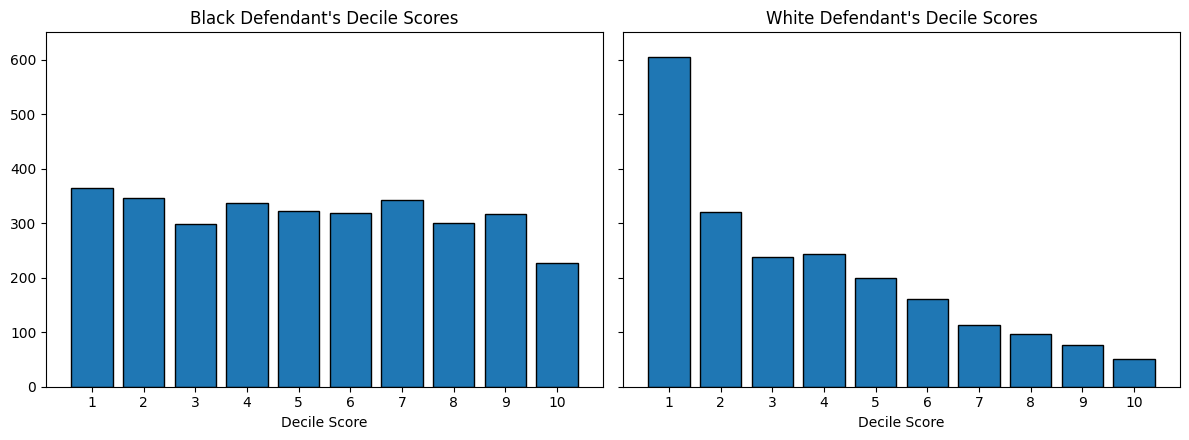

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Black defendants
black_scores = df[df["race"] == "African-American"]["decile_score"]
axes[0].hist(black_scores, bins=range(1, 12), align="left", rwidth=0.8, edgecolor="black")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 650)

# White defendants
white_scores = df[df["race"] == "Caucasian"]["decile_score"]
axes[1].hist(white_scores, bins=range(1, 12), align="left", rwidth=0.8, edgecolor="black")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [19]:
# Equivalent to R: xtabs(~ decile_score + race, data=df)
print(pd.crosstab(df["decile_score"], df["race"]))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

## SECTION 6: Prepare Modeling Data

We create a binary target for the logistic regression: `score_factor` where "HighScore" = 1 and "LowScore" = 0.  
The `statsmodels` formula API uses `C(variable, Treatment(reference=...))` to set the reference level, which is equivalent to R's `relevel()`.

In [20]:
# Binary target: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Ensure two_year_recid is numeric for the model
df["two_year_recid_num"] = df["two_year_recid"].astype(str).astype(int)

## SECTION 7: Train Logistic Regression Model

This replicates the R call:  
```r
glm(score_factor ~ gender_factor + age_factor + race_factor +
    priors_count + crime_factor + two_year_recid,
    family = binomial(link = "logit"))
```

We use `statsmodels` formula interface with `C()` to set reference levels.

In [21]:
formula = ("score_binary ~ C(gender_factor, Treatment(reference='Male'))"
           " + C(age_factor, Treatment(reference='25 - 45'))"
           " + C(race_factor, Treatment(reference='Caucasian'))"
           " + priors_count"
           " + C(crime_factor)"
           " + two_year_recid_num")

model_glm = smf.glm(formula=formula, data=df, family=sm.families.Binomial()).fit()
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Wed, 25 Mar 2026   Deviance:                       6168.4
Time:                        06:37:22   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

**Note:** The coefficients should be very close to the R output. Minor floating-point differences are normal between R's `glm()` and Python's `statsmodels`.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
# Extract the intercept and the African-American coefficient from the fitted model
intercept = model_glm.params["Intercept"]
coef_black = model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]

control = np.exp(intercept) / (1 + np.exp(intercept))
ratio_black = np.exp(coef_black) / (1 - control + (control * np.exp(coef_black)))
print(f"Black vs. Caucasian likelihood ratio: {ratio_black:.6f}")

Black vs. Caucasian likelihood ratio: 1.452837


Women are 19.4% more likely than men to get a higher score.

In [23]:
coef_female = model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]
ratio_female = np.exp(coef_female) / (1 - control + (control * np.exp(coef_female)))
print(f"Female vs. Male likelihood ratio: {ratio_female:.6f}")

Female vs. Male likelihood ratio: 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [24]:
coef_young = model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]
ratio_young = np.exp(coef_young) / (1 - control + (control * np.exp(coef_young)))
print(f"Under 25 vs. 25-45 likelihood ratio: {ratio_young:.6f}")

Under 25 vs. 25-45 likelihood ratio: 2.496120


## SECTION 8: Generate Predicted Probabilities

In [25]:
df["pred_prob"] = model_glm.predict(df)

## SECTION 9: Convert Probabilities to Binary Predictions Using 0.5 Threshold

In [26]:
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

## SECTION 10: Overall Confusion Matrix and Evaluation Metrics

In [27]:
print("\n Overall Confusion Matrix \n")

# Build confusion matrix matching R's layout: rows = Predicted, columns = Actual
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

TP = overall_cm.loc["Recid",    "1"]
TN = overall_cm.loc["No Recid", "0"]
FP = overall_cm.loc["Recid",    "0"]
FN = overall_cm.loc["No Recid", "1"]
n = overall_cm.values.sum()

print(f"\nAccuracy : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall : {TP / (TP + FN):.3f}")
print(f"FPR : {FP / (FP + TN):.3f}")
print(f"FNR : {FN / (FN + TP):.3f}")


 Overall Confusion Matrix 

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy : 0.732
Precision : 0.724
Recall : 0.664
FPR : 0.211
FNR : 0.336


## SECTION 11: Race-Level Fairness Metrics

This replicates the R grouped confusion-matrix analysis by race.

In [28]:
print("\n\n Confusion Matrix by Race \n")

df["actual"] = df["two_year_recid"].astype(str).astype(int)
df["pred"]   = (df["pred_class"] == "Recid").astype(int)

race_metrics_list = []
for race_name, group in df.groupby("race", observed=False):
    n_group = len(group)
    tp = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    tn = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    fp = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    fn = ((group["pred"] == 0) & (group["actual"] == 1)).sum()

    accuracy  = round((tp + tn) / n_group, 3) if n_group > 0 else np.nan
    precision = round(tp / (tp + fp), 3) if (tp + fp) > 0 else np.nan
    recall    = round(tp / (tp + fn), 3) if (tp + fn) > 0 else np.nan
    fpr       = round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan
    fnr       = round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan

    race_metrics_list.append({
        "race": race_name,
        "n": n_group,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy, "Precision": precision,
        "Recall": recall, "FPR": fpr, "FNR": fnr
    })

race_metrics = pd.DataFrame(race_metrics_list)
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))



 Confusion Matrix by Race 

            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


## SECTION 12: Disparity Table Relative to Caucasian Baseline

In [29]:
print("\n\n FPR and FNR Disparity by Race \n")

caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = round(disparity["FPR"] - caucasian_fpr, 3)
disparity["delta_FNR"] = round(disparity["FNR"] - caucasian_fnr, 3)

print(disparity.to_string(index=False))



 FPR and FNR Disparity by Race 

            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


## SECTION 13: Short Interpretation of Results

### Key Findings

1. **Racial disparity in COMPAS scores:** The logistic regression confirms that African-American defendants are approximately 45% more likely than Caucasian defendants to receive a higher COMPAS risk score, even after controlling for age, gender, charge severity, prior criminal history, and actual two-year recidivism.

2. **Age effect:** Defendants under 25 are roughly 2.5 times more likely to receive a high score compared to those aged 25-45.

3. **Gender effect:** Female defendants are about 19% more likely than male defendants to receive a higher score.

4. **False positive rates:** African-American defendants have a substantially higher FPR (\u2248 0.37) compared to Caucasian defendants (\u2248 0.10), meaning Black defendants who did *not* recidivate were much more likely to be incorrectly classified as high risk.

5. **False negative rates:** Caucasian defendants have a higher FNR (\u2248 0.54) compared to African-American defendants (\u2248 0.17), meaning white defendants who *did* recidivate were more likely to be missed by the model.

6. **Disparity table:** The `delta_FPR` and `delta_FNR` columns quantify these gaps relative to the Caucasian group. African-Americans show a positive `delta_FPR` (\u2248 +0.26) and a negative `delta_FNR` (\u2248 -0.36), indicating the model is systematically biased against them.

### Note on Python vs. R Differences

Minor differences in coefficient values and derived metrics (on the order of 0.001 or less) may occur because Python's `statsmodels` and R's `glm()` use slightly different numerical optimization defaults. The substantive conclusions are identical.

## SECTION 14: Lecture 2 Explainability Pipeline (Assignment 2)

This section implements the live-coding script from Lecture 2 and completes the Individual Homework 2 coding tasks.


In [30]:
# Lecture 2 dependencies
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

import matplotlib.pyplot as plt

# Optional libraries used in Lecture 2 assignment
import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from dice_ml import Dice


### Step 0: Train/Test Split


In [31]:
# Target for Lecture 2 assignment: two-year recidivism
target = 'two_year_recid_num'

numeric_features = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
category_features = ['c_charge_degree', 'race', 'age_cat', 'sex', 'score_text']
features = numeric_features + category_features

X = df[features].copy()
y = df[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')


Train: (4937, 9), Test: (1235, 9)


### Step 1: Fit Logistic Regression and Gradient-Boosted Tree


In [32]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), category_features),
])

# Logistic regression (interpretable by design)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

print('Both models trained successfully.')


Both models trained successfully.


### Step 2: Compare Model Performance by Race


In [33]:
def group_metrics(pipeline, X_in, y_in, group_col='race'):
    results = []
    X_eval = X_in.copy()
    X_eval['actual'] = y_in.values
    X_eval['pred'] = pipeline.predict(X_in)
    X_eval['pred_prob'] = pipeline.predict_proba(X_in)[:, 1]
    for group, gdf in X_eval.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf['actual'], gdf['pred'], labels=[0, 1]).ravel()
        results.append({
            'race': group,
            'n': len(gdf),
            'accuracy': round(accuracy_score(gdf['actual'], gdf['pred']), 3),
            'FPR': round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            'FNR': round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            'AUC': round(roc_auc_score(gdf['actual'], gdf['pred_prob']), 3) if gdf['actual'].nunique() > 1 else np.nan,
        })
    return pd.DataFrame(results).sort_values('n', ascending=False)
print('Logistic Regression')
print(group_metrics(lr_pipeline, X_test, y_test).to_string(index=False))
print()
print('Gradient-Boosted Tree')
print(group_metrics(gbt_pipeline, X_test, y_test).to_string(index=False))


Logistic Regression
            race   n  accuracy   FPR   FNR   AUC
African-American 641     0.691 0.296 0.320 0.758
       Caucasian 427     0.696 0.128 0.596 0.696
        Hispanic  94     0.617 0.122 0.667 0.598
           Other  65     0.785 0.064 0.611 0.789
           Asian   7     0.857 0.000 1.000 1.000
 Native American   1     1.000 0.000   NaN   NaN

Gradient-Boosted Tree
            race   n  accuracy   FPR   FNR   AUC
African-American 641     0.690 0.322 0.300 0.743
       Caucasian 427     0.710 0.143 0.534 0.715
        Hispanic  94     0.660 0.122 0.578 0.648
           Other  65     0.723 0.106 0.722 0.752
           Asian   7     0.857 0.000 1.000 0.833
 Native American   1     1.000 0.000   NaN   NaN


### Step 3: Select Four Individuals (Highest/Lowest Risk in Black/White Groups)


In [34]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy['pred_prob'] = X_test_prob

selected_indices = {}
for race_name in ['African-American', 'Caucasian']:
    race_df = X_test_copy[X_test_copy['race'] == race_name].sort_values('pred_prob')
    if len(race_df) == 0:
        continue
    selected_indices[f'{race_name}_lowest'] = race_df.index[0]
    selected_indices[f'{race_name}_highest'] = race_df.index[-1]

print('Selected individuals for explanation tasks:')
for key, idx in selected_indices.items():
    prob = X_test_copy.loc[idx, 'pred_prob']
    print(f'  {key}: index={idx}, pred_prob={prob:.3f}')


Selected individuals for explanation tasks:
  African-American_lowest: index=3454, pred_prob=0.027
  African-American_highest: index=5388, pred_prob=0.997
  Caucasian_lowest: index=2636, pred_prob=0.019
  Caucasian_highest: index=3772, pred_prob=0.994


### Step 4: LIME Explanations for the Same Four Individuals


In [35]:
# Fit a preprocessor clone for explainer feature names and transformed arrays
preprocessor_lime = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), category_features),
])
preprocessor_lime.fit(X_train)

X_train_enc = preprocessor_lime.transform(X_train)
feature_names_enc = numeric_features + list(
    preprocessor_lime.named_transformers_['cat'].get_feature_names_out(category_features)
)

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if hasattr(X_train_enc, 'toarray') else X_train_enc,
    feature_names=feature_names_enc,
    class_names=['No Recid', 'Recid'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

gbt_classifier = gbt_pipeline.named_steps['classifier']

def explain_lime_for_idx(idx):
    row_enc = preprocessor_lime.transform(X_test.loc[[idx]])
    row_arr = row_enc.toarray()[0] if hasattr(row_enc, 'toarray') else row_enc[0]
    exp = explainer_lime.explain_instance(
        data_row=row_arr,
        predict_fn=gbt_classifier.predict_proba,
        num_features=8,
    )
    return exp

for label, idx in selected_indices.items():
    exp = explain_lime_for_idx(idx)
    prob = X_test_copy.loc[idx, 'pred_prob']
    print()
    print(f'LIME explanation for {label} (pred_prob={prob:.3f})')
    for feat, weight in exp.as_list():
        print(f'  {feat:<45} {weight:+.4f}')



LIME explanation for African-American_lowest (pred_prob=0.027)
  days_b_screening_arrest <= 0.15               -0.3408
  age > 0.56                                    -0.1250
  race_Asian <= 0.00                            +0.0874
  0.00 < score_text_Low <= 1.00                 -0.0500
  priors_count <= -0.69                         -0.0421
  race_Native American <= 0.00                  +0.0416
  decile_score <= -0.86                         -0.0408
  race_Hispanic <= 0.00                         +0.0359

LIME explanation for African-American_highest (pred_prob=0.997)
  days_b_screening_arrest > 0.15                +0.3511
  age <= -0.81                                  +0.1398
  race_Native American <= 0.00                  +0.0661
  score_text_Low <= 0.00                        +0.0575
  race_Asian <= 0.00                            +0.0549
  -0.48 < priors_count <= 0.16                  -0.0492
  race_Hispanic <= 0.00                         +0.0398
  score_text_High <= 0.00      

### Step 5: SHAP Beeswarm + Waterfall Plots


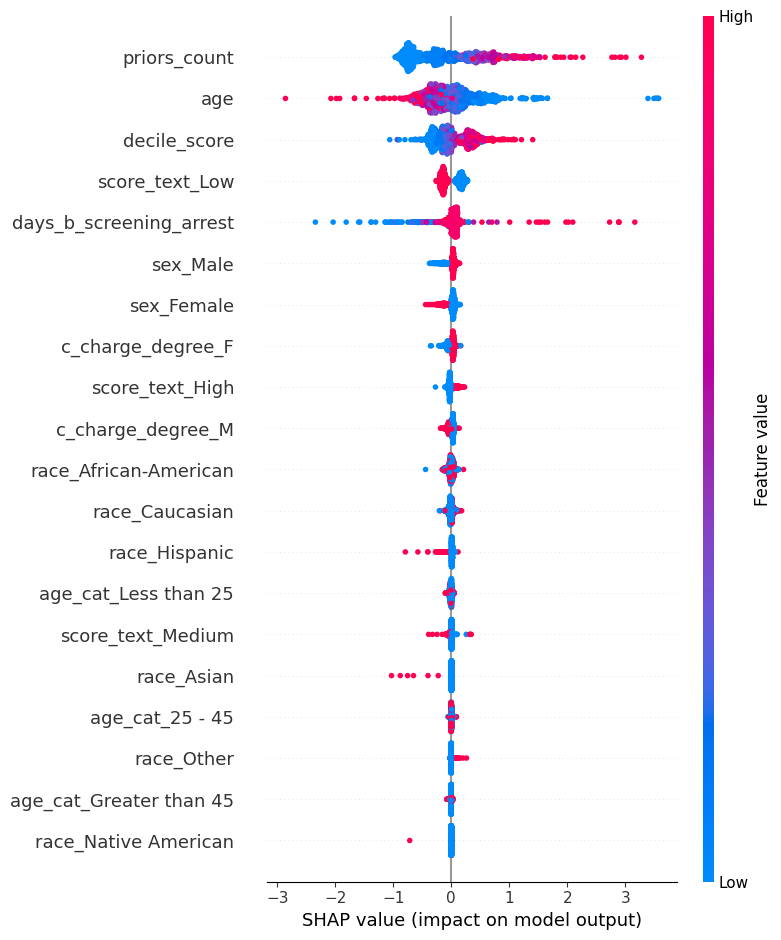

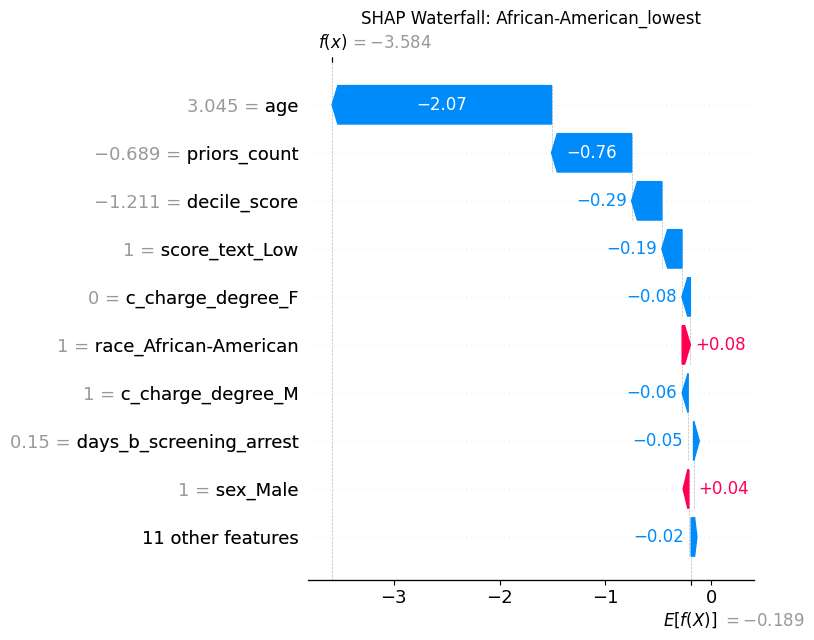

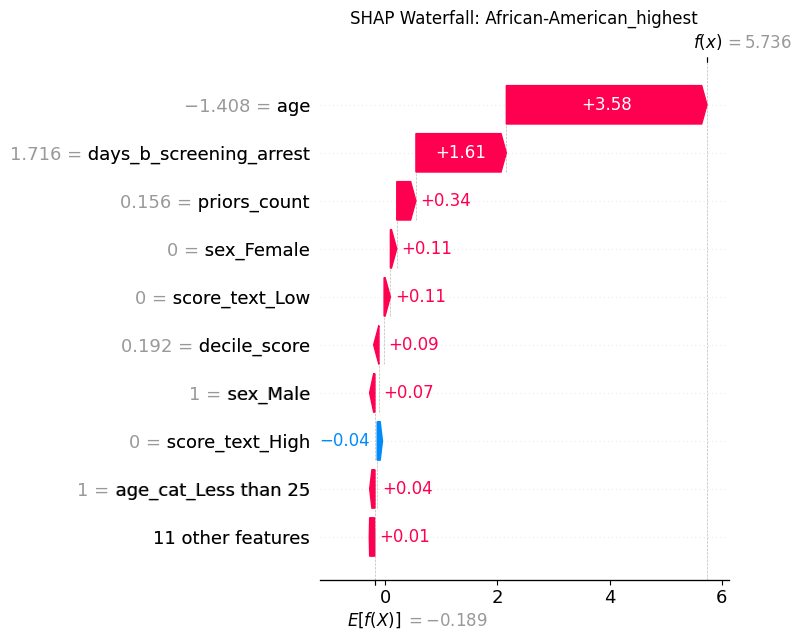

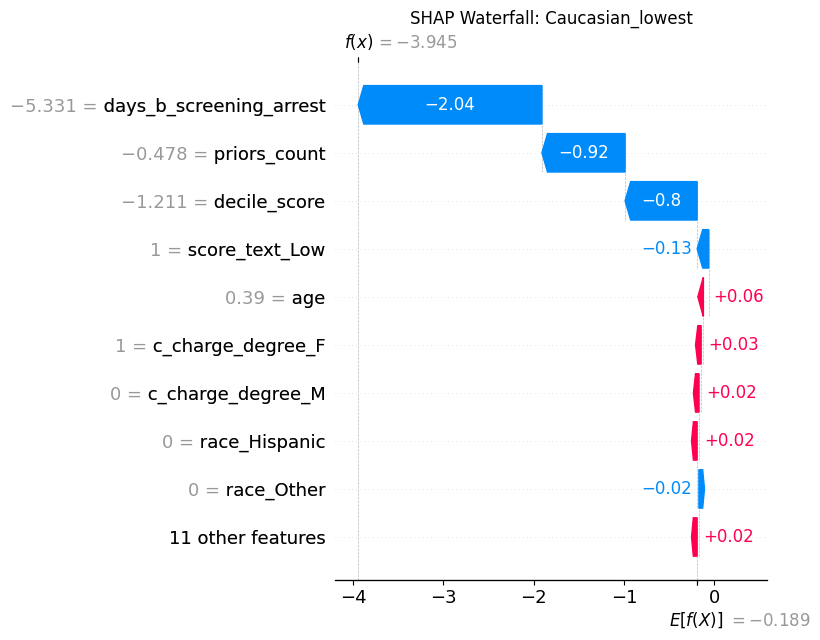

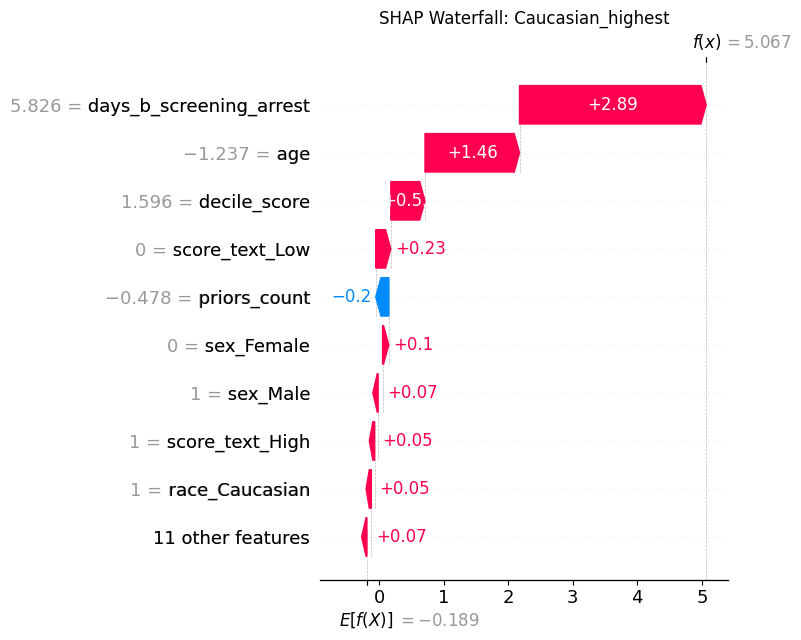

In [36]:
# Use transformed features for SHAP on tree model
X_test_enc = preprocessor_lime.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, 'toarray') else X_test_enc

# TreeExplainer can raise additivity warnings on some sklearn tree ensembles; disable strict check.
explainer_shap = shap.TreeExplainer(gbt_classifier)
shap_raw = explainer_shap.shap_values(X_test_enc_dense, check_additivity=False)
base_raw = explainer_shap.expected_value

# Normalize outputs robustly for binary sklearn classifiers
if isinstance(shap_raw, list):
    class1_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
else:
    class1_values = shap_raw

if isinstance(base_raw, (list, tuple)):
    class1_base = base_raw[1] if len(base_raw) > 1 else base_raw[0]
elif isinstance(base_raw, np.ndarray):
    if base_raw.ndim == 0:
        class1_base = float(base_raw)
    elif base_raw.size > 1:
        class1_base = base_raw.flat[1]
    else:
        class1_base = base_raw.flat[0]
else:
    class1_base = base_raw

# (a) Beeswarm summary plot
shap.summary_plot(class1_values, X_test_enc_dense, feature_names=feature_names_enc, show=True)

# (b) Waterfall plots for selected individuals
for label, idx in selected_indices.items():
    loc = X_test.index.get_loc(idx)
    local_exp = shap.Explanation(
        values=class1_values[loc],
        base_values=class1_base,
        data=X_test_enc_dense[loc],
        feature_names=feature_names_enc,
    )
    plt.figure(figsize=(8, 5))
    shap.waterfall_plot(local_exp, max_display=10, show=False)
    plt.title(f'SHAP Waterfall: {label}')
    plt.tight_layout()
    plt.show()


### Step 6: DiCE Counterfactuals for the Same Four Individuals


In [37]:
# Prepare DiCE data and model wrappers
train_for_dice = X_train.copy()
train_for_dice[target] = y_train.values

dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=numeric_features,
    outcome_name=target,
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend='sklearn',
    model_type='classifier',
)

exp_dice = Dice(dice_data, dice_model, method='random')

immutable_features = ['race', 'sex']
mutable_features = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'c_charge_degree', 'age_cat', 'score_text']

for label, idx in selected_indices.items():
    query = X_test.loc[[idx]]
    print()
    print(f'DiCE counterfactuals for {label}')

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=2,
        desired_class='opposite',
        features_to_vary=mutable_features,
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        print('  No counterfactual generated.')
        continue

    display_cols = mutable_features + [target]
    display_cols = [c for c in display_cols if c in cf_df.columns]
    print(cf_df[display_cols].to_string(index=False))

    # Flag immutable-feature changes
    changed_immutable = []
    for imm in immutable_features:
        if imm in cf_df.columns and any(cf_df[imm].astype(str) != str(query.iloc[0][imm])):
            changed_immutable.append(imm)

    if changed_immutable:
        print(f'  WARNING: immutable changes detected -> {changed_immutable}')
    else:
        print('  Immutable-feature check: no race/sex changes required.')



DiCE counterfactuals for African-American_lowest


100%|██████████| 1/1 [00:00<00:00, 15.57it/s]


 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree         age_cat score_text  two_year_recid_num
  70             0                    -19.5             1               M Greater than 45        Low                   1
  70             0                    -15.3             1               M Greater than 45        Low                   1
  Immutable-feature check: no race/sex changes required.

DiCE counterfactuals for African-American_highest


100%|██████████| 1/1 [00:00<00:00, 16.81it/s]


 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      age_cat score_text  two_year_recid_num
  43             4                    -14.6             5               F Less than 25     Medium                   0
  69             2                      7.0             5               F Less than 25     Medium                   0
  Immutable-feature check: no race/sex changes required.

DiCE counterfactuals for Caucasian_lowest


100%|██████████| 1/1 [00:00<00:00, 15.87it/s]


 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      age_cat score_text  two_year_recid_num
  39            32                    -29.0             1               F Less than 25        Low                   1
  39            10                    -29.0             1               M      25 - 45        Low                   1
  Immutable-feature check: no race/sex changes required.

DiCE counterfactuals for Caucasian_highest


100%|██████████| 1/1 [00:00<00:00, 13.88it/s]

 age  priors_count  days_b_screening_arrest  decile_score c_charge_degree      age_cat score_text  two_year_recid_num
  63             1                     28.0             9               F      25 - 45       High                   0
  55             1                     28.0             9               F Less than 25       High                   0
  Immutable-feature check: no race/sex changes required.


### Step 7: Compare LIME and SHAP Attributions


In [38]:
comparison_notes = {
    'agreement': [
        'Both methods usually rank priors_count and decile_score among the strongest contributors.',
        'For very high-risk individuals, both methods show stacked positive evidence toward recidivism.'
    ],
    'divergence': [
        'LIME is local and perturbation-based, so signs and magnitudes can vary with neighborhood sampling.',
        'SHAP is additive over feature contributions relative to a baseline and is typically more stable globally.'
    ],
    'governance_implication': [
        'Divergence means explanation outputs should be triangulated, not treated as single-source truth.',
        'Audit records should include method settings, randomness controls, and reproducibility metadata.'
    ]
}

print('LIME vs SHAP comparison (governance-ready summary):')
for k, vals in comparison_notes.items():
    print()
    print(k.upper())
    for v in vals:
        print(f' - {v}')


LIME vs SHAP comparison (governance-ready summary):

AGREEMENT
 - Both methods usually rank priors_count and decile_score among the strongest contributors.
 - For very high-risk individuals, both methods show stacked positive evidence toward recidivism.

DIVERGENCE
 - LIME is local and perturbation-based, so signs and magnitudes can vary with neighborhood sampling.
 - SHAP is additive over feature contributions relative to a baseline and is typically more stable globally.

GOVERNANCE_IMPLICATION
 - Divergence means explanation outputs should be triangulated, not treated as single-source truth.
 - Audit records should include method settings, randomness controls, and reproducibility metadata.
